# **Vanishing/Exploding Gradient Problem**

1. The **vanishing gradient problem** occurs when gradients become exponentially small as they are backpropagated. Eventually, they approach zero, so earlier layers stop learning. (gradient → 0)

2. The **exploding gradient problem** occurs when gradients grow exponentially large, leading to unstable updates. (gradient → ∞)

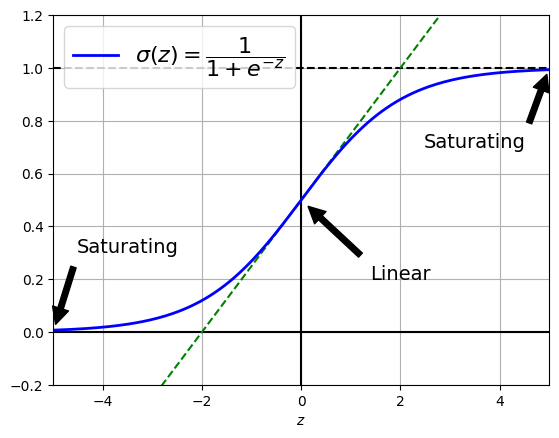

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-5, 5, 200)

plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [1, 1], 'k--')
plt.plot([0, 0], [-0.2, 1.2], 'k-')
plt.plot([-5, 5], [-3/4, 7/4], 'g--')
plt.plot(z, sigmoid(z), "b-", linewidth=2,
         label=r"$\sigma(z) = \dfrac{1}{1+e^{-z}}$")
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Saturating', xytext=(3.5, 0.7), xy=(5, 1), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Saturating', xytext=(-3.5, 0.3), xy=(-5, 0), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Linear', xytext=(2, 0.2), xy=(0, 0.5), arrowprops=props,
             fontsize=14, ha="center")
plt.grid(True)
plt.axis([-5, 5, -0.2, 1.2])
plt.xlabel("$z$")
plt.legend(loc="upper left", fontsize=16)

plt.show()

# **Weight Initialization Techniques**

## **Xavier and He Initialization**

1. Xavier (Glorot) Initialization
- Designed for symmetric activations (zero-centered) (tanh, sigmoid)
- Maintain equal variance of inputs and outputs of each layer $Var(Wx) \approx Var(x)$
- Uniform version
$$W ∼ U \Biggl(-\sqrt\frac{6}{n_{in} + {n_{out}}}, \sqrt\frac{6}{n_{in} + {n_{out}}}\Biggl)$$
- Normal version
$$W ∼ N \Biggl(0, \frac{2}{n_{in} + {n_{out}}}\Biggl)$$

2. He Initialization
- Relu, Leaky ReLU, ELU
- Uniform version
$$W ∼ U \Biggl(-\sqrt\frac{6}{n_{in}}, \sqrt\frac{6}{n_{in}}\Biggl)$$
- Normal version
$$W ∼ N \Biggl(0, \frac{2}{n_{in}}\Biggl)$$

3. Lecun Intialization
- Designed for self-normalizing or near-linear activations (SELU)
- Uniform version
$$W ∼ U \Biggl(-\sqrt\frac{3}{n_{in}}, \sqrt\frac{3}{n_{in}}\Biggl)$$
- Normal version
$$W ∼ N \Biggl(0, \frac{1}{n_{in}}\Biggl)$$

By default, Keras uses Glorot initialization with a uniform distribution. When creating a layer

In [1]:
import tensorflow as tf

dense = tf.keras.layers.Dense(
    50,
    activation="relu",
    kernel_initializer="he_normal"
)

c:\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.

In [3]:
he_avg_init = tf.keras.initializers.VarianceScaling(
    scale=2., 
    mode="fan_avg",
    distribution="uniform"
)

dense = tf.keras.layers.Dense(
    50, 
    activation="sigmoid",
    kernel_initializer=he_avg_init
)

# **Nonsaturating Activation Functions**

## **Leaky ReLU**

1. Leaky ReLU is an activation function that fixes ReLU’s “dying neuron” problem by allowing a small, non-zero gradient when the input is negative.
$$f(x) =\begin{cases}x & \text{if } x > 0 \\\alpha x & \text{if } x \leq 0
\end{cases}  \text{ with }\alpha \in (0, 1)$$
2. ReLU outputs 0 for all 𝑥<0
3. Gradient is 0 → neuron can stop learning permanently (dying ReLU)
4. 𝛼=0.01

Types of Relu:
1. **Randomized leaky ReLU (RReLU)**, where α is picked randomly in a given range during training and is fixed to an average value during testing.
2. **Parametric leaky ReLU (PReLU)**, where α is authorized to be learned during training

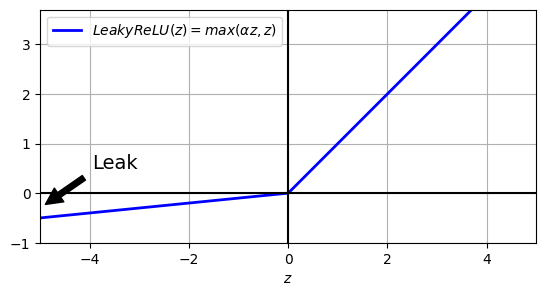

In [4]:
def leaky_relu(z, alpha):
    return np.maximum(alpha * z, z)

z = np.linspace(-5, 5, 200)
plt.plot(z, leaky_relu(z, 0.1), "b-", linewidth=2, label=r"$LeakyReLU(z) = max(\alpha z, z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([0, 0], [-1, 3.7], 'k-')
plt.grid(True)
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Leak', xytext=(-3.5, 0.5), xy=(-5, -0.3), arrowprops=props,
             fontsize=14, ha="center")
plt.xlabel("$z$")
plt.axis([-5, 5, -1, 3.7])
plt.gca().set_aspect("equal")
plt.legend()

plt.show()

In [5]:
leaky_relu = tf.keras.layers.LeakyReLU(alpha=0.2)

dense = tf.keras.layers.Dense(
    50, 
    activation=leaky_relu,
    kernel_initializer="he_normal"
)

c:\Python311\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [6]:
model = tf.keras.models.Sequential([
    # [...]  # more layers
    tf.keras.layers.Dense(50, kernel_initializer="he_normal"),  # no activation
    tf.keras.layers.LeakyReLU(alpha=0.2),  # activation as a separate layer
    # [...]  # more layers
])

## **ELU (Exponential Linear Unit)**

1. ELU is a smooth activation function that outputs negative values for negative inputs, which helps keep activations closer to zero mean and improves gradient flow.
$$f(x) =\begin{cases}x & \text{if } x > 0 \\\alpha(e^{x} - 1) & \text{if } x \leq 0
\end{cases}  \text{ with }\alpha > 0$$
2. Common choice: 𝛼=1
3. Faster Convergence

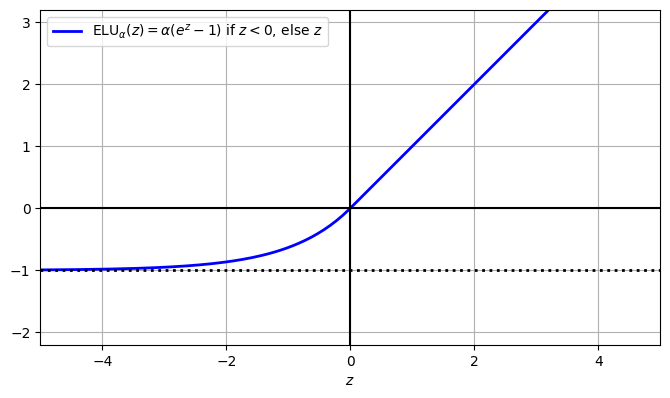

In [7]:
def elu(z, alpha=1):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

plt.figure(figsize=(8, 8))
z = np.linspace(-5, 5, 200)
plt.plot(z, elu(z), "b-", linewidth=2, label=r"ELU$_\alpha(z) = \alpha (e^z - 1)$ if $z < 0$, else $z$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1, -1], 'k:', linewidth=2)
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-5, 5, -2.2, 3.2])
plt.xlabel("$z$")
plt.gca().set_aspect("equal")
plt.legend()

plt.show()

## **SELU (Scaled SLU)**

1. SELU is an activation function designed to make neural networks self-normalizing—activations automatically converge to zero mean and unit variance without batch normalization.
$$f(x) =\begin{cases}x & \text{if } x > 0 \\\alpha(e^{x} - 1) & \text{if } x \leq 0
\end{cases}$$

2. Fixed constants (not tunable):
- α≈1.6733
- λ≈1.0507

alpha_0_1 = 1.6732632423543778 
 scale_0_1 = 1.0507009873554805


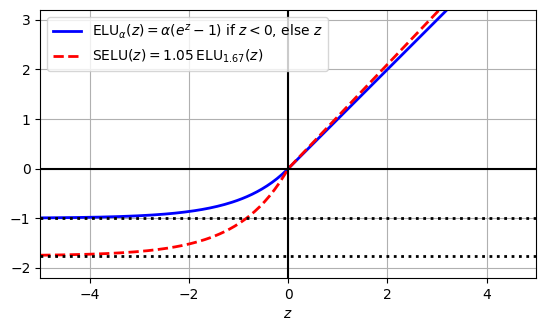

In [8]:
from scipy.special import erfc

# alpha and scale to self normalize with mean 0 and standard deviation 1
alpha_0_1 = -np.sqrt(2 / np.pi) / (erfc(1 / np.sqrt(2)) * np.exp(1 / 2) - 1)
scale_0_1 = (
    (1 - erfc(1 / np.sqrt(2)) * np.sqrt(np.e))
    * np.sqrt(2 * np.pi)
    * (
        2 * erfc(np.sqrt(2)) * np.e ** 2
        + np.pi * erfc(1 / np.sqrt(2)) ** 2 * np.e
        - 2 * (2 + np.pi) * erfc(1 / np.sqrt(2)) * np.sqrt(np.e)
        + np.pi
        + 2
    ) ** (-1 / 2)
)

print(f"alpha_0_1 = {alpha_0_1}", "\n", f"scale_0_1 = {scale_0_1}")

def elu(z, alpha=1):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

def selu(z, scale=scale_0_1, alpha=alpha_0_1):
    return scale * elu(z, alpha)

z = np.linspace(-5, 5, 200)
plt.plot(z, elu(z), "b-", linewidth=2, label=r"ELU$_\alpha(z) = \alpha (e^z - 1)$ if $z < 0$, else $z$")
plt.plot(z, selu(z), "r--", linewidth=2, label=r"SELU$(z) = 1.05 \, $ELU$_{1.67}(z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1, -1], 'k:', linewidth=2)
plt.plot([-5, 5], [-1.758, -1.758], 'k:', linewidth=2)
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-5, 5, -2.2, 3.2])
plt.xlabel("$z$")
plt.gca().set_aspect("equal")
plt.legend()

plt.show()

### **1. self-regularized network using SELU**

Let's create a neural net for Fashion MNIST with 100 hidden layers, using the SELU activation function:

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(28, 28)))
model.add(tf.keras.layers.Flatten())

for _ in range(100):
    model.add(tf.keras.layers.Dense(
        100, 
        activation="selu",
        kernel_initializer="lecun_normal"
        )
    )

model.add(tf.keras.layers.Dense(10, activation="softmax"))

c:\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    metrics=["accuracy"]
)

Now let's train it. Do not forget to scale the inputs to mean 0 and standard deviation 1:

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]
X_train, X_valid, X_test = X_train / 255, X_valid / 255, X_test / 255

In [3]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [4]:
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)

X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

In [14]:
history = model.fit(
    X_train_scaled, y_train, 
    epochs=5,
    validation_data=(X_valid_scaled, y_valid)
)

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.5347 - loss: 1.2223 - val_accuracy: 0.6454 - val_loss: 0.9446
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.6711 - loss: 0.8656 - val_accuracy: 0.5006 - val_loss: 1.4628
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.7295 - loss: 0.7224 - val_accuracy: 0.7788 - val_loss: 0.6134
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.7858 - loss: 0.5878 - val_accuracy: 0.7896 - val_loss: 0.5867
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 43s 22ms/step - accuracy: 0.8045 - loss: 0.5384 - val_accuracy: 0.7958 - val_loss: 0.5702


#### **Using ReLU activation for the same problem**

In [5]:
tf.random.set_seed(42)

In [16]:
model = tf.keras.Sequential()

model.add(tf.keras.Input(shape=(28, 28)))
model.add(tf.keras.layers.Flatten())

for _ in range(100):
    model.add(tf.keras.layers.Dense(
        100,
        activation="relu",
        kernel_initializer="he_normal"
    ))

model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [17]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    metrics=["accuracy"]
)

In [18]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=5,
    validation_data=(X_valid_scaled, y_valid)
)

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - accuracy: 0.2028 - loss: 2.0113 - val_accuracy: 0.2682 - val_loss: 1.8273
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3074 - loss: 1.6725 - val_accuracy: 0.4528 - val_loss: 1.3672
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4743 - loss: 1.2591 - val_accuracy: 0.5170 - val_loss: 1.1481
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6016 - loss: 0.9919 - val_accuracy: 0.6298 - val_loss: 0.9140
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6653 - loss: 0.8750 - val_accuracy: 0.6748 - val_loss: 0.8755


we suffered from the vanishing/exploding gradients problem.

## **GELU, Swish and Mish**

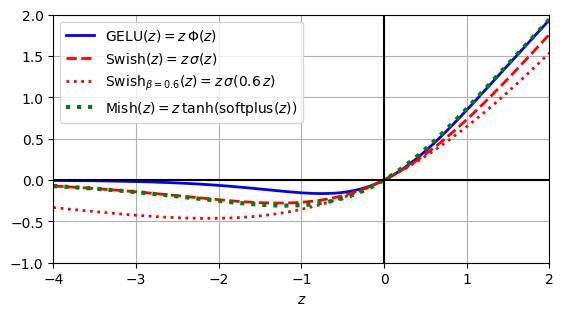

In [19]:
def swish(z, beta=1):
    return z * sigmoid(beta * z)

def approx_gelu(z):
    return swish(z, beta=1.702)

def softplus(z):
    return np.log(1 + np.exp(z))

def mish(z):
    return z * np.tanh(softplus(z))

z = np.linspace(-4, 2, 200)

beta = 0.6
plt.plot(z, approx_gelu(z), "b-", linewidth=2,
         label=r"GELU$(z) = z\,\Phi(z)$")
plt.plot(z, swish(z), "r--", linewidth=2,
         label=r"Swish$(z) = z\,\sigma(z)$")
plt.plot(z, swish(z, beta), "r:", linewidth=2,
         label=fr"Swish$_{{\beta={beta}}}(z)=z\,\sigma({beta}\,z)$")
plt.plot(z, mish(z), "g:", linewidth=3,
         label=fr"Mish$(z) = z\,\tanh($softplus$(z))$")
plt.plot([-4, 2], [0, 0], 'k-')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-4, 2, -1, 2])
plt.gca().set_aspect("equal")
plt.xlabel("$z$")
plt.legend(loc="upper left")

plt.show()

# **Batch Normalization**

Batch Normalization is a layer-wise normalization technique that stabilizes and accelerates training by controlling the distribution of activations.

In [20]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [21]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(
        300,
        activation="relu",
        kernel_initializer="he_normal"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(
        100,
        activation="relu",
        kernel_initializer="he_normal"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 784)            │         3,136 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,346 (1.04 MB)

 Trainable params: 268,978 (1.03 MB)

 Non-trainable params: 2,368 (9.25 KB)

As you can see, each BN layer adds four parameters per input: γ, β, μ, and σ (for example, the first BN layer adds 3,136 parameters, which is 4 × 784). The last two parameters, μ and σ, are the moving averages; they are not affected by backpropagation, so Keras calls them “non-trainable”9 (if you count the total number of BN parameters, 3,136 + 1,200 + 400, and divide by 2, you get 2,368, which is the total number of non-trainable parameters in this model).

In [23]:
# parameters of first BN layer
[(var.name, var.shape, var.trainable) for var in model.layers[1].variables]

[('gamma', TensorShape([784]), True),
 ('beta', TensorShape([784]), True),
 ('moving_mean', TensorShape([784]), False),
 ('moving_variance', TensorShape([784]), False)]

In [24]:
model.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer="sgd",
    metrics=["accuracy"]
)

model.fit(
    X_train, y_train, 
    epochs=2, 
    validation_data=(X_valid, y_valid)
)

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8059 - loss: 0.5590 - val_accuracy: 0.8568 - val_loss: 0.3956
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8593 - loss: 0.3979 - val_accuracy: 0.8706 - val_loss: 0.3655


Sometimes applying BN before the activation function works better (there's a debate on this topic). Moreover, the layer before a BatchNormalization layer does not need to have bias terms, since the BatchNormalization layer some as well, it would be a waste of parameters, so you can set use_bias=False when creating those layers:

In [25]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [26]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, kernel_initializer="he_normal", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dense(100, kernel_initializer="he_normal", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [27]:
[(var.name, var.shape, var.trainable) for var in model.layers[2].variables]

[('gamma', TensorShape([300]), True),
 ('beta', TensorShape([300]), True),
 ('moving_mean', TensorShape([300]), False),
 ('moving_variance', TensorShape([300]), False)]

In [28]:
model.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer="sgd",
    metrics=["accuracy"]
)

model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7982 - loss: 0.6050 - val_accuracy: 0.8394 - val_loss: 0.4293
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8538 - loss: 0.4214 - val_accuracy: 0.8572 - val_loss: 0.3848


# **Gradient Clipping**

1. During backpropagation, gradients can grow very large. This can cause, Numerical instability (NaNs, infs), Overshooting minima, Training divergence. Gradient clipping caps the gradient magnitude before the optimizer step.

Types:
1. Clip by value0
- Clamps each gradient component independently
- Can distort gradient direction
$$g_{i}​=clip(g_{i}​,−c,c)$$

2. Clip by norm
- Rescales gradients so their global norm does not exceed a threshold
- Preserves gradient direction
$$g <- g . \frac{\text(max_{norm})}{max(||g||, max_{norm})}$$

In [29]:
# clip by value 
optimizer = tf.keras.optimizers.SGD(clipvalue=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8708 - loss: 0.3711 - val_accuracy: 0.8658 - val_loss: 0.3639
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8824 - loss: 0.3369 - val_accuracy: 0.8746 - val_loss: 0.3494


In [30]:
# clip by norm
optimizer = tf.keras.optimizers.SGD(clipnorm=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8939 - loss: 0.3031 - val_accuracy: 0.8794 - val_loss: 0.3361
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8989 - loss: 0.2873 - val_accuracy: 0.8814 - val_loss: 0.3331


# **Reusing Pretrained Layers**

## **Reusing a Keras model**

Let's split the fashion MNIST training set in two:

**X_train_A**: all images of all items except for T-shirts/tops and pullovers (classes 0 and 2).
**X_train_B**: a much smaller training set of just the first 200 images of T-shirts/tops and pullovers.
The validation set and the test set are also split this way, but without restricting the number of images.

We will train a model on set A (classification task with 8 classes), and try to reuse it to tackle set B (binary classification). We hope to transfer a little bit of knowledge from task A to task B, since classes in set A (trousers, dresses, coats, sandals, shirts, sneakers, bags, and ankle boots) are somewhat similar to classes in set B (T-shirts/tops and pullovers). However, since we are using Dense layers, only patterns that occur at the same location can be reused (in contrast, convolutional layers will transfer much better, since learned patterns can be detected anywhere on the image).

In [31]:
pos_class_id = class_names.index("Pullover")
neg_class_id = class_names.index("T-shirt/top")

def split_dataset(X, y):
    y_for_B = (y == pos_class_id) | (y == neg_class_id)
    y_A = y[~y_for_B]
    y_B = (y[y_for_B] == pos_class_id).astype(np.float32)
    old_class_ids = list(set(range(10)) - set([neg_class_id, pos_class_id]))
    for old_class_id, new_class_id in zip(old_class_ids, range(8)):
        y_A[y_A == old_class_id] = new_class_id  # reorder class ids for A
    return ((X[~y_for_B], y_A), (X[y_for_B], y_B))

(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]

tf.random.set_seed(42)

In [32]:
model_A = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(8, activation="softmax")
])

model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])

history = model_A.fit(X_train_A, y_train_A, epochs=20,
                      validation_data=(X_valid_A, y_valid_A))

model_A.save("my_model_A.keras")

Epoch 1/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6151 - loss: 1.2537 - val_accuracy: 0.7756 - val_loss: 0.7520
Epoch 2/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8078 - loss: 0.6265 - val_accuracy: 0.8368 - val_loss: 0.5212
Epoch 3/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8518 - loss: 0.4827 - val_accuracy: 0.8599 - val_loss: 0.4342
Epoch 4/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8674 - loss: 0.4178 - val_accuracy: 0.8691 - val_loss: 0.3907
Epoch 5/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8754 - loss: 0.3811 - val_accuracy: 0.8747 - val_loss: 0.3642
Epoch 6/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8813 - loss: 0.3569 - val_accuracy: 0.8784 - val_loss: 0.3462
Epoch 7/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8858 - loss: 0.3395 - val_accuracy: 0.8832 - val_loss: 0.3328
Epoch 8/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8896 - loss: 0.3259 - 

In [33]:
# train and evaluate model B, without reusing model A

tf.random.set_seed(42)
model_B = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_B.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])

history = model_B.fit(X_train_B, y_train_B, epochs=20,
                      validation_data=(X_valid_B, y_valid_B))

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.4350 - loss: 0.7791 - val_accuracy: 0.4975 - val_loss: 0.7041
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4900 - loss: 0.7070 - val_accuracy: 0.5875 - val_loss: 0.6595
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5750 - loss: 0.6584 - val_accuracy: 0.6775 - val_loss: 0.6261
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6600 - loss: 0.6211 - val_accuracy: 0.7755 - val_loss: 0.5989
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7400 - loss: 0.5911 - val_accuracy: 0.8160 - val_loss: 0.5757
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8250 - loss: 0.5654 - val_accuracy: 0.8457 - val_loss: 0.5549
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8800 - loss: 0.5423 - val_accuracy: 0.8615 - val_loss: 0.5359
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9100 - loss: 0.5209 - val_accuracy: 0.8734 - val_loss: 0.5182


Model B reaches 91.85% accuracy on the test set. Now let's try reusing the pretrained model A.

In [34]:
model_A = tf.keras.models.load_model("my_model_A.keras")
model_B_on_A = tf.keras.Sequential(model_A.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

Note that model_B_on_A and model_A actually share layers now, so when we train one, it will update both models. If we want to avoid that, we need to build model_B_on_A on top of a clone of model_A:

In [35]:
tf.random.set_seed(42)

In [36]:
model_A_clone = tf.keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())

In [37]:
# creating model_B_on_A just like in the previous cell
model_B_on_A = tf.keras.Sequential(model_A_clone.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

Freeze the reused layers during the first few epochs, giving the new
layer some time to learn reasonable weights. To do this, set every layer’s trainable attribute to False and compile the model

In [38]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])

In [39]:
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=4,
                           validation_data=(X_valid_B, y_valid_B))

for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=16,
                           validation_data=(X_valid_B, y_valid_B))

Epoch 1/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4750 - loss: 0.8116 - val_accuracy: 0.5302 - val_loss: 0.7149
Epoch 2/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4900 - loss: 0.7483 - val_accuracy: 0.5678 - val_loss: 0.6993
Epoch 3/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5350 - loss: 0.7357 - val_accuracy: 0.5964 - val_loss: 0.6882
Epoch 4/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5400 - loss: 0.7226 - val_accuracy: 0.6123 - val_loss: 0.6766
Epoch 1/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6000 - loss: 0.6895 - val_accuracy: 0.6874 - val_loss: 0.6300
Epoch 2/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6600 - loss: 0.6300 - val_accuracy: 0.7468 - val_loss: 0.5778
Epoch 3/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7400 - loss: 0.5744 - val_accuracy: 0.7844 - val_loss: 0.5335
Epoch 4/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7700 - loss: 0.5272 - val_accuracy: 0.8071 - val_loss: 0.4964
Epoc

In [40]:
model_B_on_A.evaluate(X_test_B, y_test_B)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9155 - loss: 0.3006


[0.3006192147731781, 0.9154999852180481]

# **Faster Optimizers**

In [5]:
def build_model(seed=42):
    tf.random.set_seed(seed)
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

def build_and_train_model(optimizer):
    model = build_model()
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    return model.fit(X_train, y_train, epochs=10,
                     validation_data=(X_valid, y_valid))

In [39]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)

history_sgd = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5652 - loss: 1.3755 - val_accuracy: 0.7154 - val_loss: 0.8883
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7328 - loss: 0.7938 - val_accuracy: 0.7700 - val_loss: 0.6990
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7740 - loss: 0.6715 - val_accuracy: 0.7938 - val_loss: 0.6206
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7955 - loss: 0.6084 - val_accuracy: 0.8078 - val_loss: 0.5744
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8085 - loss: 0.5678 - val_accuracy: 0.8122 - val_loss: 0.5434
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8168 - loss: 0.5395 - val_accuracy: 0.8178 - val_loss: 0.5214
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8224 - loss: 0.5186 - val_accuracy: 0.8212 - val_loss: 0.5049
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8268 - loss: 0.5023 - 

## **Momentum optimization**

1. Momentum is an enhancement to gradient descent that accelerates convergence—especially in ravines where the gradient oscillates across dimensions (common in deep networks). Instead of updating parameters using only the current gradient, momentum maintains a velocity vector that accumulates past gradients.

2. Velocity update
$$v_{t+1} = \beta v_{t} + \eta\nabla L(\theta_{t})$$

3. Parameter update
$$\theta_{t+1} = \theta_{t} - v_{t+1}$$

where,
- $\nabla$ = learning rate
- $v_{t}$ = velocity
- $\beta \in (0, 1)$ momentum coefficient (typically 0.9)

4. Due to the momentum, the optimizer may overshoot a bit, then come back, overshoot again, and oscillate like this many times before stabilizing at the minimum.

In [41]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

In [42]:
history_momentum = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7593 - loss: 0.7075 - val_accuracy: 0.8184 - val_loss: 0.5014
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 147s 86ms/step - accuracy: 0.8368 - loss: 0.4645 - val_accuracy: 0.8358 - val_loss: 0.4457
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8528 - loss: 0.4188 - val_accuracy: 0.8460 - val_loss: 0.4177
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8618 - loss: 0.3914 - val_accuracy: 0.8542 - val_loss: 0.3990
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8681 - loss: 0.3717 - val_accuracy: 0.8586 - val_loss: 0.3895
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8736 - loss: 0.3561 - val_accuracy: 0.8622 - val_loss: 0.3796
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8779 - loss: 0.3432 - val_accuracy: 0.8642 - val_loss: 0.3719
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8817 - loss: 0.3325

## **Nesterov Accelerated Gradient(NAG)**

1. Nesterov Accelerated Gradient is a momentum-based optimization algorithm that improves upon classical momentum by anticipating where the parameters will be and computing the gradient at that look-ahead point.

2. Before taking a step, first look where momentum is about to take you.

3. look-ahead step
$$\eta_{t} = \eta_{t} - \beta_{v_{t-1}}$$

In [43]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9,
                                    nesterov=True)

In [44]:
history_nesterov = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7679 - loss: 0.6828 - val_accuracy: 0.8272 - val_loss: 0.4873
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8376 - loss: 0.4595 - val_accuracy: 0.8416 - val_loss: 0.4388
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8514 - loss: 0.4151 - val_accuracy: 0.8524 - val_loss: 0.4147
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8612 - loss: 0.3889 - val_accuracy: 0.8568 - val_loss: 0.3995
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8674 - loss: 0.3699 - val_accuracy: 0.8604 - val_loss: 0.3878
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8729 - loss: 0.3546 - val_accuracy: 0.8608 - val_loss: 0.3826
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8772 - loss: 0.3416 - val_accuracy: 0.8620 - val_loss: 0.3763
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8803 - loss: 0.3306 

# **Adaptive learning**

## **AdaGrad**

1. AdaGrad is an adaptive learning-rate optimization algorithm that automatically scales the learning rate per parameter based on historical gradient information.

- larger gradients $G_{t}$ -> smaller learning rates
- small gradients $G_{t}$ -> larger learning rates

2. Updates Rules (element-wise)
$$G_{t} = G_{t-1} + g_{t} ⊗ g_{t}$$
$$\theta_{t+1} = \theta_{t} - \frac{\eta}{\sqrt{G_{t}} + \epsilon} ⊘ g_{t}$$

3. The Learning Rate Death Spiral, as learning rate progresses:
$$G_{t} -> ∞ -> \frac{\eta}{\sqrt{G_{t}}} -> 0$$
- The effective learning rate decays to zero. The model freezes before reaching the optimum. Training simply stops making progress.

In [26]:
optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.001)

In [27]:
history_adagrad = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6792 - loss: 1.0328 - val_accuracy: 0.7802 - val_loss: 0.6837
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7915 - loss: 0.6409 - val_accuracy: 0.8058 - val_loss: 0.5834
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8117 - loss: 0.5733 - val_accuracy: 0.8188 - val_loss: 0.5396
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8209 - loss: 0.5381 - val_accuracy: 0.8260 - val_loss: 0.5134
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8282 - loss: 0.5152 - val_accuracy: 0.8322 - val_loss: 0.4953
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8335 - loss: 0.4986 - val_accuracy: 0.8358 - val_loss: 0.4820
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8372 - loss: 0.4860 - val_accuracy: 0.8380 - val_loss: 0.4716
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8401 - loss: 0.4758 - 

## **RMSProp (Root Mean Square Propagation)**

1. RMSProp adjusts the learning rate per parameter by normalizing gradients using a moving average of recent squared gradients. This prevents the learning rate from becoming too large (as in vanilla SGD) or decaying too aggressively (as in AdaGrad).

2. Moving average of the squared gradients
$$v_{t} = \rho v_{t-1} + (1 - \rho)g^{2}_{t}$$

3. Parameter update
$$\theta_{t+1} = \theta_{t} - \frac{\eta}{\sqrt v_{t} + \epsilon}g_{t}$$

In [28]:
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)

In [29]:
history_rmsprop = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8141 - loss: 0.5122 - val_accuracy: 0.8394 - val_loss: 0.4261
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8591 - loss: 0.3899 - val_accuracy: 0.8596 - val_loss: 0.3880
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8704 - loss: 0.3666 - val_accuracy: 0.8522 - val_loss: 0.4326
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8758 - loss: 0.3546 - val_accuracy: 0.8538 - val_loss: 0.4639
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8780 - loss: 0.3450 - val_accuracy: 0.8594 - val_loss: 0.4348
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8819 - loss: 0.3392 - val_accuracy: 0.8520 - val_loss: 0.5392
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8832 - loss: 0.3365 - val_accuracy: 0.8706 - val_loss: 0.4569
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8852 - loss: 0.3317 - 

## **Adam and Nadam Optimization**

1. **Adam (Adaptive Moment Estimation)** is a first-order stochastic optimization algorithm that combines momentum and RMSProp-style adaptive learning rates. It is one of the most widely used optimizers in deep learning.

2. First and second moment estimates
$$m_{t} = \beta_{1}m_{t-1} + (1 - \beta_{1})g_{t}$$
$$v_{t} = \beta_{2}v_{t-1} + (1 - \beta_{2})g_{t}^{2}$$

3. Bias correction
$$\hat{m_{t}} = frac{m_{t}}{1 - \beta^{t}_{1}}$$
$$\hat{v_{t}} = frac{v_{t}}{1 - \beta^{t}_{2}}$$

4. Parameter update
$$\theta_{t+1} = \theta_{t} - \frac{\eta}{\sqrt v_{t} + \epsilon}g_{t}$$

5. Typical hyperparameters

- Learning rate $\eta$: 0.001
- $\beta_{1}$: 0.9 (momentum)
- $\beta_{2}$: 0.999 (variance decay)
- $\epsilon$: 1e-8

In [30]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

In [31]:
history_adam = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8224 - loss: 0.4965 - val_accuracy: 0.8280 - val_loss: 0.4344
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8641 - loss: 0.3741 - val_accuracy: 0.8256 - val_loss: 0.4362
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8765 - loss: 0.3373 - val_accuracy: 0.8562 - val_loss: 0.3824
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8848 - loss: 0.3134 - val_accuracy: 0.8424 - val_loss: 0.4360
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8900 - loss: 0.2956 - val_accuracy: 0.8628 - val_loss: 0.3708
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8964 - loss: 0.2813 - val_accuracy: 0.8666 - val_loss: 0.3747
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9013 - loss: 0.2662 - val_accuracy: 0.8552 - val_loss: 0.4258
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9050 - loss: 0.2541 - 

### **1. Adamax**

1. Adamax is a variant of Adam based on the ∞-norm (L-infinity norm) of past gradients instead of the L² norm used in standard Adam. It is designed to be more numerically stable and simpler in practice.

2. First moment (same as Adam)
$$m_{t} = \beta_{1}m_{t-1} + (1 - \beta_{1})g_{t}$$

3. Exponential infinity norm
$$u_{t} = max(\beta_{2}u_{t-1}, |g_{t}|)$$

4. Bias correction (only for first moment, no correction needed for $u_{t}$)
$$\hat{m_{t}} = frac{m_{t}}{1 - \beta^{t}_{1}}$$

5. Parameter update
$$\theta_{t+1} = \theta_{t} - \frac{\eta}{u_{t}}\hat{m_{t}}$$

In [32]:
optimizer = tf.keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

In [33]:
history_adamax = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8085 - loss: 0.5505 - val_accuracy: 0.8318 - val_loss: 0.4568
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8567 - loss: 0.4011 - val_accuracy: 0.8486 - val_loss: 0.4082
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8705 - loss: 0.3611 - val_accuracy: 0.8542 - val_loss: 0.3877
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8787 - loss: 0.3351 - val_accuracy: 0.8604 - val_loss: 0.3766
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8854 - loss: 0.3160 - val_accuracy: 0.8644 - val_loss: 0.3650
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8907 - loss: 0.3004 - val_accuracy: 0.8648 - val_loss: 0.3638
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8952 - loss: 0.2870 - val_accuracy: 0.8674 - val_loss: 0.3570
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9008 - loss: 0.2750 - 

### **2. Nadam**

Nadam optimization is Adam optimization plus the Nesterov trick, so it will
often converge slightly faster than Adam

In [34]:
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

In [35]:
history_nadam = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8290 - loss: 0.4790 - val_accuracy: 0.8442 - val_loss: 0.4082
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8661 - loss: 0.3654 - val_accuracy: 0.8514 - val_loss: 0.3965
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8785 - loss: 0.3316 - val_accuracy: 0.8692 - val_loss: 0.3684
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8855 - loss: 0.3078 - val_accuracy: 0.8620 - val_loss: 0.3769
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8923 - loss: 0.2893 - val_accuracy: 0.8716 - val_loss: 0.3593
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8983 - loss: 0.2736 - val_accuracy: 0.8780 - val_loss: 0.3476
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9021 - loss: 0.2617 - val_accuracy: 0.8808 - val_loss: 0.3525
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9055 - loss: 0.2514 - 

### **3. Adamw**

1. AdamW is the recommended modern variant of Adam that fixes Adam’s incorrect handling of weight decay by decoupling weight decay from the gradient update.

2. Parameter update with decoupled weight decay
$$\theta_{t+1} = (1 - \eta\lambda)\theta_{t} - \eta\frac{\hat{m_{t}}}{\sqrt{\hat{v_{t}} + \epsilon}} \text{ where, }\lambda \text{ weight decay coeffient}$$

In [36]:
optimizer = tf.keras.optimizers.AdamW(weight_decay=1e-5, learning_rate=0.001, beta_1=0.9, beta_2=0.999)

In [37]:
history_adamw = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8211 - loss: 0.5039 - val_accuracy: 0.8372 - val_loss: 0.4080
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8634 - loss: 0.3726 - val_accuracy: 0.8484 - val_loss: 0.3915
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8765 - loss: 0.3352 - val_accuracy: 0.8496 - val_loss: 0.3892
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8832 - loss: 0.3141 - val_accuracy: 0.8516 - val_loss: 0.3928
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8898 - loss: 0.2970 - val_accuracy: 0.8646 - val_loss: 0.3623
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8951 - loss: 0.2810 - val_accuracy: 0.8562 - val_loss: 0.3865
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8994 - loss: 0.2682 - val_accuracy: 0.8726 - val_loss: 0.3480
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9041 - loss: 0.2559 - 

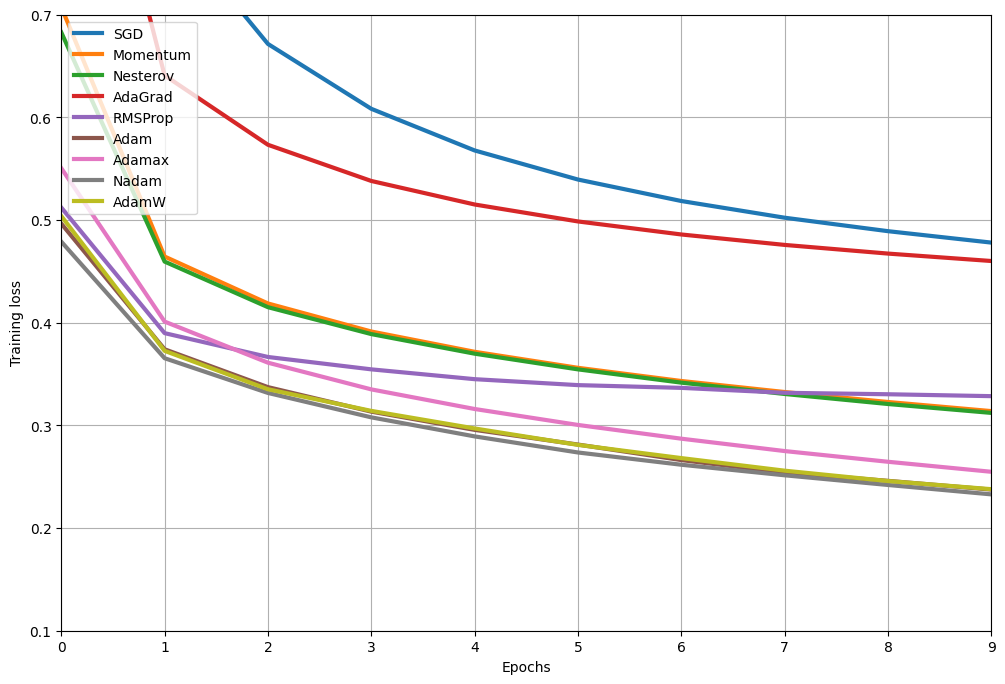

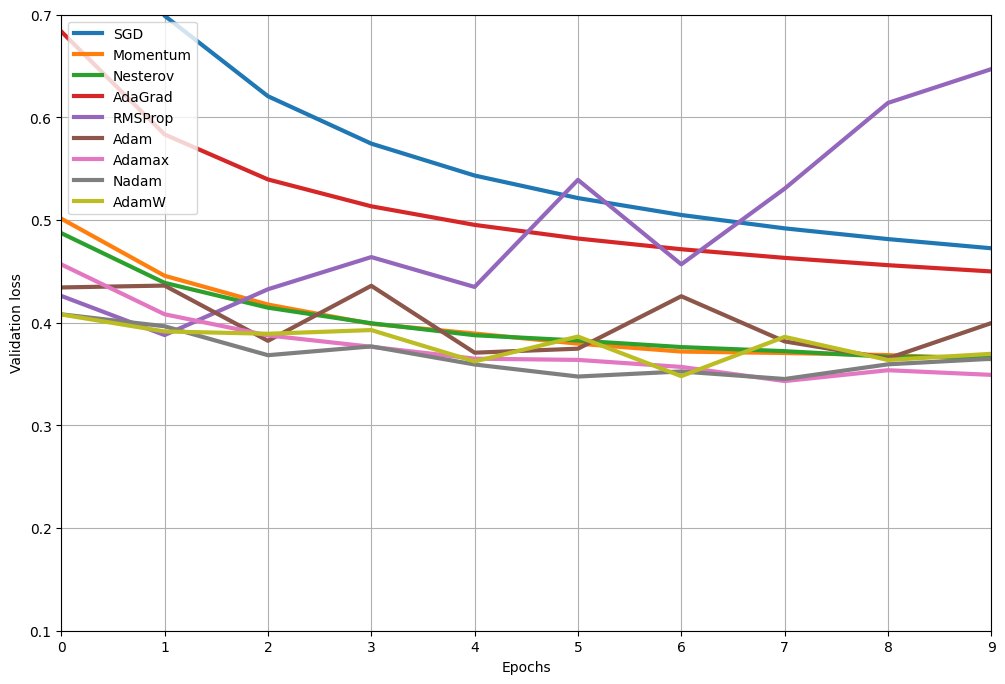

In [46]:
for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "SGD Momentum Nesterov AdaGrad RMSProp Adam Adamax Nadam AdamW"
    
    for history, opt_name in zip((history_sgd, history_momentum, history_nesterov,
                                  history_adagrad, history_rmsprop, history_adam,
                                  history_adamax, history_nadam, history_adamw),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"loss": "Training loss", "val_loss": "Validation loss"}[loss])
    plt.legend(loc="upper left")
    plt.axis([0, 9, 0.1, 0.7])
    plt.show()

# **Learning Rate Scheduling**

Learning rate scheduling is the practice of changing the learning rate (LR) during training to improve convergence speed, stability, and final model performance. It’s one of the highest-leverage hyperparameters in deep learning.

### **1. Power Scheduling**

1. Reduces the learning rate by a factor (e.g., 0.1) every few $k$ epochs.

2. learning_rate = initial_learning_rate / (1 + step / decay_steps)**power
Keras uses power = 1.
$$\eta_{t} = \eta_{0} . \gamma^{[t/k]}$$

**Note**: Optimizers used to have a decay argument for this, but it was deprecated. You must use the schedulers in tf.keras.optimizers.schedules instead.

In [6]:
lr_scheduling = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=0.01,
    decay_steps=10_000,
    decay_rate=1,
    staircase=False
)

optimizer = tf.keras.optimizers.SGD(learning_rate=lr_scheduling)

The InverseTimeDecay scheduler uses learning_rate = initial_learning_rate / (1 + decay_rate * step / decay_steps). If you set staircase=True, then it replaces step / decay_step with floor(step / decay_step).

In [9]:
history_power_scheduling = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7632 - loss: 0.6934 - val_accuracy: 0.8316 - val_loss: 0.4861
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8323 - loss: 0.4752 - val_accuracy: 0.8428 - val_loss: 0.4402
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8488 - loss: 0.4299 - val_accuracy: 0.8508 - val_loss: 0.4196
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8574 - loss: 0.4039 - val_accuracy: 0.8542 - val_loss: 0.4072
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8634 - loss: 0.3860 - val_accuracy: 0.8564 - val_loss: 0.3984
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8678 - loss: 0.3724 - val_accuracy: 0.8584 - val_loss: 0.3896
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8710 - loss: 0.3617 - val_accuracy: 0.8596 - val_loss: 0.3834
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8739 - loss: 0.3526 - 

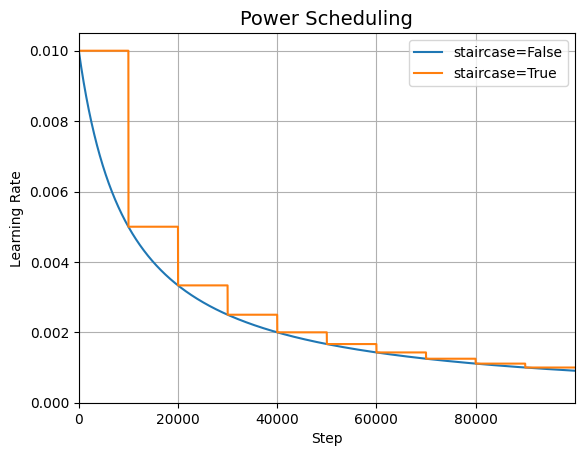

In [13]:
#  plots power scheduling with staircase=True or False

initial_learning_rate = 0.01
decay_rate = 1.0
decay_steps = 10_000

steps = np.arange(100_000)
lrs = initial_learning_rate / (1 + decay_rate * steps / decay_steps)
lrs2 = initial_learning_rate / (1 + decay_rate * np.floor(steps / decay_steps))

plt.plot(steps, lrs,  "-", label="staircase=False")
plt.plot(steps, lrs2,  "-", label="staircase=True")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Power Scheduling", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

### **2. Exponential Scheduling**

1. Continuously decays LR.
- learning_rate = initial_learning_rate * decay_rate ** (step / decay_steps)
$$\eta_{t} = \eta_{0} . e^{-\lambda t}$$

2. Gradually reduces the learning rate according to an exponential function.

In [14]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=20_000,
    decay_rate=0.1,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

In [15]:
history_exponential_scheduling = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7627 - loss: 0.6904 - val_accuracy: 0.8222 - val_loss: 0.4947
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8330 - loss: 0.4741 - val_accuracy: 0.8372 - val_loss: 0.4522
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8496 - loss: 0.4297 - val_accuracy: 0.8452 - val_loss: 0.4328
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8577 - loss: 0.4051 - val_accuracy: 0.8506 - val_loss: 0.4171
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8623 - loss: 0.3886 - val_accuracy: 0.8550 - val_loss: 0.4047
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8669 - loss: 0.3767 - val_accuracy: 0.8584 - val_loss: 0.3938
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8697 - loss: 0.3677 - val_accuracy: 0.8598 - val_loss: 0.3866
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8723 - loss: 0.3608 - 

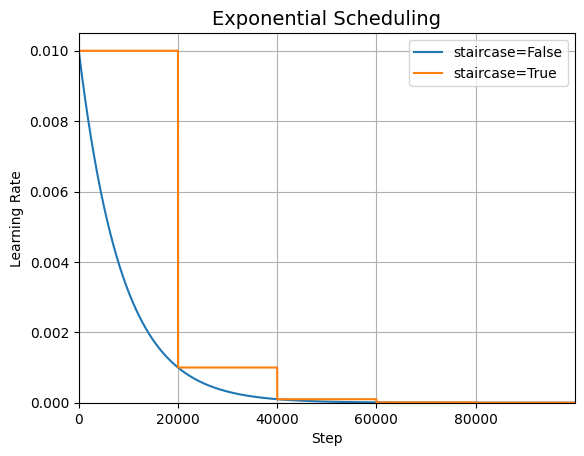

In [16]:
# plots exponential scheduling

initial_learning_rate = 0.01
decay_rate = 0.1
decay_steps = 20_000

steps = np.arange(100_000)
lrs = initial_learning_rate * decay_rate ** (steps / decay_steps)
lrs2 = initial_learning_rate * decay_rate ** np.floor(steps / decay_steps)

plt.plot(steps, lrs,  "-", label="staircase=False")
plt.plot(steps, lrs2,  "-", label="staircase=True")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Exponential Scheduling", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

Keras also provides a LearningRateScheduler callback class that lets you define your own scheduling function. Let's see how you could use it to implement exponential decay. Note that in this case the learning rate only changes at each epoch, not at each step:

In [20]:
def exponential_decay_fn(epoch):
    return 0.01 * 0.1 ** (epoch / 20)

In [21]:
def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1 ** (epoch / s)
    return exponential_decay_fn

exponential_decay_fn = exponential_decay(lr0=0.01, s=20)

In [22]:
tf.random.set_seed(42)
model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [23]:
n_epochs = 20

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(exponential_decay_fn)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7696 - loss: 0.6798 - val_accuracy: 0.8320 - val_loss: 0.4770 - learning_rate: 0.0100
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8359 - loss: 0.4649 - val_accuracy: 0.8464 - val_loss: 0.4305 - learning_rate: 0.0089
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8521 - loss: 0.4189 - val_accuracy: 0.8514 - val_loss: 0.4121 - learning_rate: 0.0079
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8607 - loss: 0.3922 - val_accuracy: 0.8530 - val_loss: 0.4003 - learning_rate: 0.0071
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8670 - loss: 0.3741 - val_accuracy: 0.8558 - val_loss: 0.3902 - learning_rate: 0.0063
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8717 - loss: 0.3604 - val_accuracy: 0.8592 - val_loss: 0.3808 - learning_rate: 0.0056
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8759 

Alternatively, the schedule function can take the current learning rate as a second argument:

In [24]:
def exponential_decay_fn(epoch, lr):
    return lr * 0.1 ** (1 / 20)

If you want to use a custom scheduling function that updates the learning rate at each iteration rather than at each epoch, you can write your own callback class like this:

In [25]:
K = tf.keras.backend

class ExponentialDecay(tf.keras.callbacks.Callback):
    def __init__(self, n_steps=40_000):
        super().__init__()
        self.n_steps = n_steps

    def on_batch_begin(self, batch, logs=None):
        # Note: the `batch` argument is reset at each epoch
        lr = self.model.optimizer.learning_rate.numpy()
        new_learning_rate = lr * 0.1 ** (1 / self.n_steps)
        self.model.optimizer.learning_rate = new_learning_rate

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = self.model.optimizer.learning_rate.numpy()

In [26]:
lr0 = 0.01
model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [27]:
import math

batch_size = 32
n_steps = n_epochs * math.ceil(len(X_train) / batch_size)
exp_decay = ExponentialDecay(n_steps)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[exp_decay])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7599 - loss: 0.7018 - val_accuracy: 0.8262 - val_loss: 0.4957 - lr: 0.0089
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8330 - loss: 0.4748 - val_accuracy: 0.8374 - val_loss: 0.4515 - lr: 0.0079
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8487 - loss: 0.4295 - val_accuracy: 0.8452 - val_loss: 0.4311 - lr: 0.0071
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8574 - loss: 0.4027 - val_accuracy: 0.8500 - val_loss: 0.4143 - lr: 0.0063
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8635 - loss: 0.3837 - val_accuracy: 0.8558 - val_loss: 0.4001 - lr: 0.0056
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8688 - loss: 0.3692 - val_accuracy: 0.8592 - val_loss: 0.3892 - lr: 0.0050
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8722 - loss: 0.3579 - val_accuracy: 0.8646 - val_loss: 0.3805 - lr: 0.0045

### **3. Piecewise Constant Scheduling**

Use a constant learning rate for a number of epochs (e.g., η0 = 0.1 for 5 epochs), then a smaller learning rate for another number of epochs (e.g., η1 = 0.001 for 50 epochs), and so on. Although this solution can work very well, it requires fiddling around to figure out the right sequence of learning rates and how long to use each of them.

In [17]:
n_epochs = 20
batch_size = 32

lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    boundaries = [50_000 * n_epochs // batch_size, 80_000 * n_epochs // batch_size] ,
    values=[0.01, 0.005, 0.001]
)

optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

In [18]:
history_piecewise_scheduling = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7613 - loss: 0.6979 - val_accuracy: 0.8312 - val_loss: 0.4744
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8340 - loss: 0.4715 - val_accuracy: 0.8420 - val_loss: 0.4346
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8493 - loss: 0.4253 - val_accuracy: 0.8488 - val_loss: 0.4161
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8589 - loss: 0.3974 - val_accuracy: 0.8544 - val_loss: 0.4027
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8655 - loss: 0.3768 - val_accuracy: 0.8568 - val_loss: 0.3948
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8705 - loss: 0.3607 - val_accuracy: 0.8576 - val_loss: 0.3905
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8748 - loss: 0.3474 - val_accuracy: 0.8592 - val_loss: 0.3868
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8792 - loss: 0.3360 

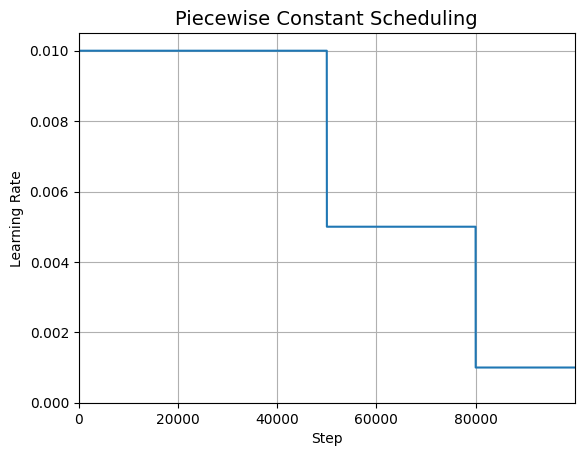

In [19]:
# plots piecewise constant scheduling

boundaries = [50_000, 80_000]
values = [0.01, 0.005, 0.001]

steps = np.arange(100_000)

lrs = np.full(len(steps), values[0])
for boundary, value in zip(boundaries, values[1:]):
    lrs[boundary:] = value

plt.plot(steps, lrs, "-")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Piecewise Constant Scheduling", fontsize=14)
plt.grid(True)
plt.show()

Just like we did with exponential scheduling, we could also implement piecewise constant scheduling manually:

In [28]:
def piecewise_constant_fn(epoch):
    if epoch < 5:
        return 0.01
    elif epoch < 15:
        return 0.005
    else:
        return 0.001

In [29]:
def piecewise_constant(boundaries, values):
    boundaries = np.array([0] + boundaries)
    values = np.array(values)
    def piecewise_constant_fn(epoch):
        return values[(boundaries > epoch).argmax() - 1]
    return piecewise_constant_fn

piecewise_constant_fn = piecewise_constant([5, 15], [0.01, 0.005, 0.001])

In [30]:
n_epochs = 25

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(piecewise_constant_fn)

model = build_model()
optimizer = tf.keras.optimizers.Nadam(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8103 - loss: 0.5363 - val_accuracy: 0.8202 - val_loss: 0.4918 - learning_rate: 0.0100
Epoch 2/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.8407 - loss: 0.4553 - val_accuracy: 0.8298 - val_loss: 0.4515 - learning_rate: 0.0100
Epoch 3/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8491 - loss: 0.4309 - val_accuracy: 0.8340 - val_loss: 0.4746 - learning_rate: 0.0100
Epoch 4/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8531 - loss: 0.4189 - val_accuracy: 0.8196 - val_loss: 0.4897 - learning_rate: 0.0100
Epoch 5/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8580 - loss: 0.4051 - val_accuracy: 0.8302 - val_loss: 0.4714 - learning_rate: 0.0100
Epoch 6/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8739 - loss: 0.3571 - val_accuracy: 0.8454 - val_loss: 0.4415 - learning_rate: 0.0050
Epoch 7/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8

We've looked at InverseTimeDecay, ExponentialDecay, and PiecewiseConstantDecay. A few more schedulers are available in tf.keras.optimizers.schedules, here is the full list:

In [31]:
for name in sorted(dir(tf.keras.optimizers.schedules)):
    if name[0] == name[0].lower():
        continue
    scheduler_class = getattr(tf.keras.optimizers.schedules, name)
    print(f"• {name} : {scheduler_class.__doc__.splitlines()[0]}")

• CosineDecay : A `LearningRateSchedule` that uses a cosine decay with optional warmup.
• CosineDecayRestarts : A `LearningRateSchedule` that uses a cosine decay schedule with restarts.
• ExponentialDecay : A `LearningRateSchedule` that uses an exponential decay schedule.
• InverseTimeDecay : A `LearningRateSchedule` that uses an inverse time decay schedule.
• LearningRateSchedule : The learning rate schedule base class.
• PiecewiseConstantDecay : A `LearningRateSchedule` that uses a piecewise constant decay schedule.
• PolynomialDecay : A `LearningRateSchedule` that uses a polynomial decay schedule.


### **4. Performance Scheduling**

Measure the validation error every N steps (just like for early stopping), and reduce the learning rate by a factor of λ when the error stops dropping.

In [32]:
model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [33]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7640 - loss: 0.6808 - val_accuracy: 0.8232 - val_loss: 0.4879 - learning_rate: 0.0100
Epoch 2/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8346 - loss: 0.4708 - val_accuracy: 0.8336 - val_loss: 0.4507 - learning_rate: 0.0100
Epoch 3/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8494 - loss: 0.4248 - val_accuracy: 0.8410 - val_loss: 0.4288 - learning_rate: 0.0100
Epoch 4/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8580 - loss: 0.3968 - val_accuracy: 0.8448 - val_loss: 0.4156 - learning_rate: 0.0100
Epoch 5/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8649 - loss: 0.3765 - val_accuracy: 0.8474 - val_loss: 0.4071 - learning_rate: 0.0100
Epoch 6/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8697 - loss: 0.3603 - val_accuracy: 0.8494 - val_loss: 0.3977 - learning_rate: 0.0100
Epoch 7/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8741 -

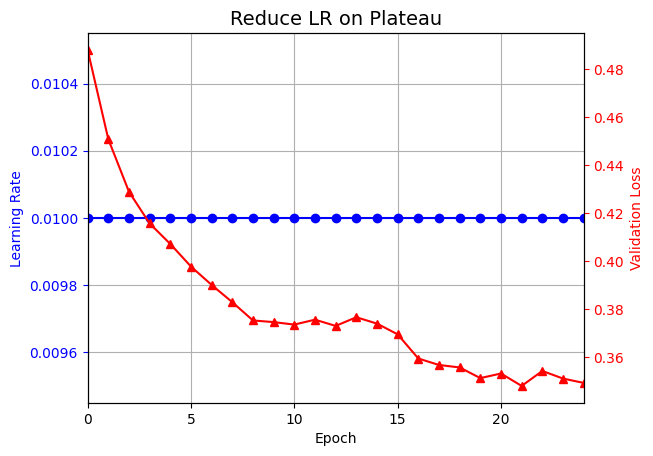

In [34]:
# plots performance scheduling

plt.plot(history.epoch, history.history["learning_rate"], "bo-")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate", color='b')
plt.tick_params('y', colors='b')
plt.gca().set_xlim(0, n_epochs - 1)
plt.grid(True)

ax2 = plt.gca().twinx()
ax2.plot(history.epoch, history.history["val_loss"], "r^-")
ax2.set_ylabel('Validation Loss', color='r')
ax2.tick_params('y', colors='r')

plt.title("Reduce LR on Plateau", fontsize=14)
plt.show()

### **5. 1Cycle scheduling**

1. Increasing the initial learning rate η0, growing linearly up to η1 halfway through training. Then it decreases the learning rate linearly down to η0 again during the second half of training, finishing the last few epochs by drop ping the rate down by several orders of magnitude (still linearly). The maximum learning rate η1 is chosen using the same approach we used to find the optimal learning rate, and the initial learning rate η0 is chosen to be roughly 10 times lower.

2. The ExponentialLearningRate custom callback updates the learning rate during training, at the end of each batch. It multiplies it by a constant factor. It also saves the learning rate and loss at each batch. Since logs["loss"] is actually the mean loss since the start of the epoch, and we want to save the batch loss instead, we must compute the mean times the number of batches since the beginning of the epoch to get the total loss so far, then we subtract the total loss at the previous batch to get the current batch's loss.

In [35]:
K = tf.keras.backend

class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_epoch_begin(self, epoch, logs=None):
        self.sum_of_epoch_losses = 0

    def on_batch_end(self, batch, logs=None):
        mean_epoch_loss = logs["loss"]  # the epoch's mean loss so far 
        new_sum_of_epoch_losses = mean_epoch_loss * (batch + 1)
        batch_loss = new_sum_of_epoch_losses - self.sum_of_epoch_losses
        self.sum_of_epoch_losses = new_sum_of_epoch_losses
        lr = self.model.optimizer.learning_rate.numpy()
        self.rates.append(lr)
        self.losses.append(batch_loss)
        self.model.optimizer.learning_rate = lr * self.factor

The find_learning_rate() function trains the model using the ExponentialLearningRate callback, and it returns the learning rates and corresponding batch losses. At the end, it restores the model and its optimizer to their initial state.

In [36]:
def find_learning_rate(model, X, y, epochs=1, batch_size=32, min_rate=1e-4,
                       max_rate=1):
    init_weights = model.get_weights()
    iterations = math.ceil(len(X) / batch_size) * epochs
    factor = (max_rate / min_rate) ** (1 / iterations)
    init_lr = K.get_value(model.optimizer.learning_rate)
    model.optimizer.learning_rate = min_rate
    exp_lr = ExponentialLearningRate(factor)
    history = model.fit(X, y, epochs=epochs, batch_size=batch_size,
                        callbacks=[exp_lr])
    model.optimizer.learning_rate = init_lr
    model.set_weights(init_weights)
    return exp_lr.rates, exp_lr.losses

The plot_lr_vs_loss() function plots the learning rates vs the losses. The optimal learning rate to use as the maximum learning rate in 1cycle is near the bottom of the curve.

In [37]:
def plot_lr_vs_loss(rates, losses):
    plt.plot(rates, losses, "b")
    plt.gca().set_xscale('log')
    max_loss = losses[0] + min(losses)
    plt.hlines(min(losses), min(rates), max(rates), color="k")
    plt.axis([min(rates), max(rates), 0, max_loss])
    plt.xlabel("Learning rate")
    plt.ylabel("Loss")
    plt.grid()

In [38]:
model = build_model()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3673 - loss: 1.9145


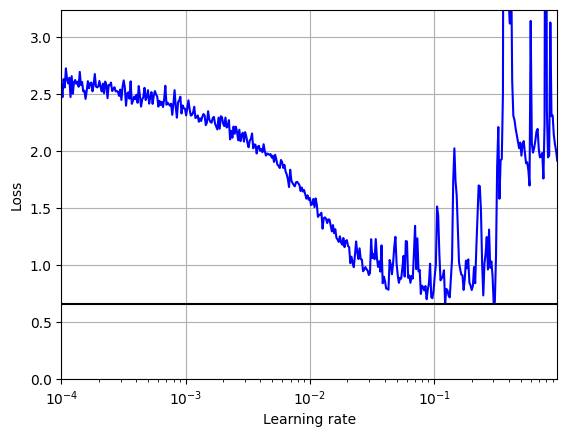

In [39]:
batch_size = 128
rates, losses = find_learning_rate(model, X_train, y_train, epochs=1,
                                   batch_size=batch_size)
plot_lr_vs_loss(rates, losses)

Looks like the max learning rate to use for 1cycle is around 10–1.

The OneCycleScheduler custom callback updates the learning rate at the beginning of each batch. It applies the logic described in the book: increase the learning rate linearly during about half of training, then reduce it linearly back to the initial learning rate, and lastly reduce it down to close to zero linearly for the very last part of training.

In [40]:
class OneCycleScheduler(tf.keras.callbacks.Callback):
    def __init__(self, iterations, max_lr=1e-3, start_lr=None,
                 last_iterations=None, last_lr=None):
        self.iterations = iterations
        self.max_lr = max_lr
        self.start_lr = start_lr or max_lr / 10
        self.last_iterations = last_iterations or iterations // 10 + 1
        self.half_iteration = (iterations - self.last_iterations) // 2
        self.last_lr = last_lr or self.start_lr / 1000
        self.iteration = 0

    def _interpolate(self, iter1, iter2, lr1, lr2):
        return (lr2 - lr1) * (self.iteration - iter1) / (iter2 - iter1) + lr1

    def on_batch_begin(self, batch, logs):
        if self.iteration < self.half_iteration:
            lr = self._interpolate(0, self.half_iteration, self.start_lr,
                                   self.max_lr)
        elif self.iteration < 2 * self.half_iteration:
            lr = self._interpolate(self.half_iteration, 2 * self.half_iteration,
                                   self.max_lr, self.start_lr)
        else:
            lr = self._interpolate(2 * self.half_iteration, self.iterations,
                                   self.start_lr, self.last_lr)
        self.iteration += 1
        self.model.optimizer.learning_rate = lr

In [41]:
model = build_model()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["accuracy"])
n_epochs = 25
onecycle = OneCycleScheduler(math.ceil(len(X_train) / batch_size) * n_epochs,
                             max_lr=0.1)
history = model.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
                    validation_data=(X_valid, y_valid),
                    callbacks=[onecycle])

Epoch 1/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6720 - loss: 0.9891 - val_accuracy: 0.7892 - val_loss: 0.6154
Epoch 2/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7999 - loss: 0.5758 - val_accuracy: 0.8246 - val_loss: 0.5067
Epoch 3/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8255 - loss: 0.4983 - val_accuracy: 0.8206 - val_loss: 0.4862
Epoch 4/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8384 - loss: 0.4567 - val_accuracy: 0.8208 - val_loss: 0.4894
Epoch 5/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8480 - loss: 0.4256 - val_accuracy: 0.8282 - val_loss: 0.4637
Epoch 6/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8551 - loss: 0.4017 - val_accuracy: 0.8312 - val_loss: 0.4582
Epoch 7/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8612 - loss: 0.3822 - val_accuracy: 0.8304 - val_loss: 0.4545
Epoch 8/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8657 - loss: 0.3658 - val_accuracy: 0.

# **Regularization**

## **1. $l_{1}$ and $l_{2}$ regularization**

In [42]:
layer = tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal",
                              kernel_regularizer=tf.keras.regularizers.l2(0.01))

Or use l1(0.1) for ℓ1 regularization with a factor of 0.1, or l1_l2(0.1, 0.01) for both ℓ1 and ℓ2 regularization, with factors 0.1 and 0.01 respectively.

In [43]:
tf.random.set_seed(42)

In [ ]:
from functools import partial

RegularizedDense = partial(tf.keras.layers.Dense,
                           activation="relu",
                           kernel_initializer="he_normal",
                           kernel_regularizer=tf.keras.regularizers.l2(0.01))

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    RegularizedDense(100),
    RegularizedDense(100),
    RegularizedDense(10, activation="softmax",
                     kernel_initializer="glorot_normal")  # he_normalization
])

In [46]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.02)

model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=2,
                    validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7666 - loss: 3.1311 - val_accuracy: 0.8244 - val_loss: 1.8642
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8141 - loss: 1.4263 - val_accuracy: 0.8246 - val_loss: 1.1196


# **Dropout**

1. With dropout regularization, at each training iteration a random subset of all neurons in one or more layers—except the output layer—are “dropped out”; these neurons output 0 at this iteration.

2. Core idea
- During each training step; Each neuron is dropped with probability 𝑝
- Remaining neurons are scaled to keep expected activations unchanged

3. For an activation $h$:
$$\hat{h} = \frac{m ⊙ h}{1 - p}, m \approx Bernoulli(1 - p)$$
- $p$: droupout rate
- $m$: binary mask
- scaling by $\frac{1}{1 - p}$ is called inverted dropout

In [10]:
tf.random.set_seed(42)

In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [12]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7561 - loss: 0.6716 - val_accuracy: 0.8276 - val_loss: 0.4516
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8149 - loss: 0.5109 - val_accuracy: 0.8440 - val_loss: 0.4160
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8247 - loss: 0.4724 - val_accuracy: 0.8532 - val_loss: 0.3948
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8333 - loss: 0.4514 - val_accuracy: 0.8472 - val_loss: 0.3951
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8411 - loss: 0.4297 - val_accuracy: 0.8584 - val_loss: 0.3774
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8454 - loss: 0.4199 - val_accuracy: 0.8646 - val_loss: 0.3615
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8485 - loss: 0.4101 - val_accuracy: 0.8668 - val_loss: 0.3611
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8520 - loss: 0.4009 - 

In [50]:
model.evaluate(X_train, y_train)

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8833 - loss: 0.3103


[0.3103116750717163, 0.8832908868789673]

In [51]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8641 - loss: 0.3697


[0.3697291910648346, 0.8640999794006348]

**Note**: make sure to use AlphaDropout instead of Dropout if you want to build a self-normalizing neural net using SELU.

## **AlphaDropout**

In [62]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(28, 28)))
model.add(tf.keras.layers.Flatten())

for _ in range(2):
    model.add(tf.keras.layers.Dense(
        100, 
        activation="selu",
        kernel_initializer="lecun_normal"
        )
    )
    model.add(tf.keras.layers.AlphaDropout(rate=0.1))

model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [65]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    metrics=["accuracy"]
)

history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8141 - loss: 0.5145 - val_accuracy: 0.8378 - val_loss: 0.4460
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8151 - loss: 0.5105 - val_accuracy: 0.8366 - val_loss: 0.4438
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8167 - loss: 0.5079 - val_accuracy: 0.8374 - val_loss: 0.4426
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8172 - loss: 0.5043 - val_accuracy: 0.8384 - val_loss: 0.4411
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8183 - loss: 0.5038 - val_accuracy: 0.8382 - val_loss: 0.4408
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8178 - loss: 0.5002 - val_accuracy: 0.8388 - val_loss: 0.4393
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8185 - loss: 0.4996 - val_accuracy: 0.8394 - val_loss: 0.4379
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8197 - loss: 0.4972 - 

In [66]:
model.evaluate(X_train, y_train)

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8463 - loss: 0.4351


[0.43506279587745667, 0.8462727069854736]

In [67]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8335 - loss: 0.4772


[0.4772254526615143, 0.8335000276565552]

## **Monte Carlo (MC) Dropout**

In [6]:
tf.random.set_seed(42)

In [13]:
y_probas = np.stack([model(X_test, training=True)
                     for sample in range(100)])
y_proba = y_probas.mean(axis=0)

In [14]:
model.predict(X_test[:1]).round(3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


array([[0.   , 0.   , 0.   , 0.   , 0.   , 0.036, 0.   , 0.196, 0.   ,
        0.767]], dtype=float32)

In [22]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

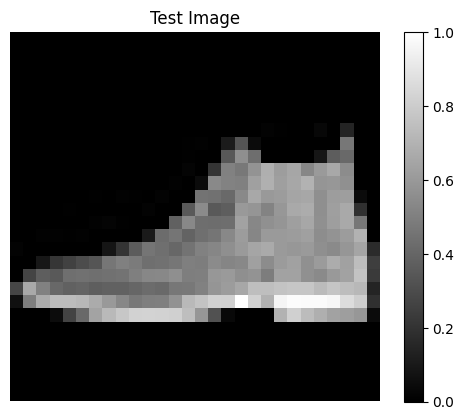

In [23]:
import matplotlib.pyplot as plt

img = X_test[0]

plt.imshow(img, cmap='gray')
plt.colorbar()
plt.title("Test Image")
plt.axis('off')
plt.show()


The model seems almost certain that this image belongs to class 9 (ankle boot)

In [24]:
y_proba[0].round(3)

array([0.   , 0.   , 0.   , 0.   , 0.   , 0.082, 0.   , 0.254, 0.001,
       0.661], dtype=float32)

In [25]:
y_std = y_probas.std(axis=0)
y_std[0].round(3)

array([0.002, 0.001, 0.   , 0.001, 0.   , 0.112, 0.   , 0.209, 0.004,
       0.232], dtype=float32)

In [26]:
y_pred = y_proba.argmax(axis=1)
accuracy = (y_pred == y_test).sum() / len(y_test)
accuracy

0.8648

In [28]:
class MCDropout(tf.keras.layers.Dropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

In [29]:
#  how to convert Dropout to MCDropout in a Sequential model
Dropout = tf.keras.layers.Dropout

mc_model = tf.keras.Sequential([
    MCDropout(layer.rate) if isinstance(layer, Dropout) else layer
    for layer in model.layers
])

mc_model.set_weights(model.get_weights())

In [30]:
mc_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout (MCDropout)          │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_1 (MCDropout)        │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_2 (MCDropout)        │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
tf.random.set_seed(42)
np.mean([mc_model.predict(X_test[:1])
         for sample in range(100)], axis=0).round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.09, 0.  , 0.27, 0.  , 0.63]],
      dtype=float32)

## **Max norm**

In [33]:
dense = tf.keras.layers.Dense(
    100,
    activation="relu",
    kernel_initializer="he_normal",
    kernel_constraint=tf.keras.constraints.max_norm(1.)
)

In [35]:
from functools import partial

MaxNormDense = partial(tf.keras.layers.Dense,
                       activation="relu",
                       kernel_initializer="he_normal",
                       kernel_constraint=tf.keras.constraints.max_norm(1.))

tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    MaxNormDense(100),
    MaxNormDense(100),
    tf.keras.layers.Dense(10, activation="softmax")
])

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8055 - loss: 0.5423 - val_accuracy: 0.8330 - val_loss: 0.4358
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8508 - loss: 0.4074 - val_accuracy: 0.8460 - val_loss: 0.4035
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8613 - loss: 0.3763 - val_accuracy: 0.8426 - val_loss: 0.4077
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8668 - loss: 0.3581 - val_accuracy: 0.8356 - val_loss: 0.4085
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8713 - loss: 0.3462 - val_accuracy: 0.8408 - val_loss: 0.4004
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8749 - loss: 0.3366 - val_accuracy: 0.8380 - val_loss: 0.4007
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8769 - loss: 0.3315 - val_accuracy: 0.8430 - val_loss: 0.3992
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8791 - loss: 0.3260 - 